In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
df = pd.read_csv("dataset_balanced_final.csv")

print(df.shape)

df.head()

(10610, 8)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Label
0,2.877713,293.983431,4.517476,13,0,12,53248,ATTACK
1,3.455120,362.939603,5.499085,19,0,19,53248,ATTACK
2,0.051562,33668.159007,96.970504,5,1,5,65535,ATTACK
3,2.422511,356.654748,3.302359,8,0,8,547,ATTACK
4,0.197157,32821.534390,45.648866,9,1,9,65535,NORMAL


In [3]:
df["Label"] = df["Label"].map({
    "NORMAL":0,
    "ATTACK":1
})

print(df["Label"].value_counts())

Label
1    5305
0    5305
Name: count, dtype: int64


In [4]:
X = df.drop("Label", axis=1)

y = df["Label"]

print(X.shape)
print(y.shape)

(10610, 7)
(10610,)


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp

)

In [6]:
print("="*60)
print("TRAIN")
print("="*60)

print(X_train.shape)

print(y_train.value_counts())

print()

print("="*60)
print("VALIDATION")
print("="*60)

print(X_val.shape)

print(y_val.value_counts())

print()

print("="*60)
print("TEST")
print("="*60)

print(X_test.shape)

print(y_test.value_counts())

TRAIN
(7427, 7)
Label
1    3714
0    3713
Name: count, dtype: int64

VALIDATION
(1591, 7)
Label
0    796
1    795
Name: count, dtype: int64

TEST
(1592, 7)
Label
1    796
0    796
Name: count, dtype: int64


In [7]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [8]:
y_val_pred = rf.predict(X_val)

y_val_prob = rf.predict_proba(X_val)[:,1]

In [9]:
print("="*60)
print("VALIDATION RESULT")
print("="*60)

print()

print("Accuracy :",
      accuracy_score(y_val,y_val_pred))

print("Precision :",
      precision_score(y_val,y_val_pred))

print("Recall :",
      recall_score(y_val,y_val_pred))

print("F1 Score :",
      f1_score(y_val,y_val_pred))

print("ROC AUC :",
      roc_auc_score(y_val,y_val_prob))

print()

print(classification_report(
    y_val,
    y_val_pred,
    target_names=["NORMAL","ATTACK"]
))

VALIDATION RESULT

Accuracy : 0.9792583280955374
Precision : 0.9810606060606061
Recall : 0.9773584905660377
F1 Score : 0.9792060491493385
ROC AUC : 0.9956780759141619

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       796
      ATTACK       0.98      0.98      0.98       795

    accuracy                           0.98      1591
   macro avg       0.98      0.98      0.98      1591
weighted avg       0.98      0.98      0.98      1591



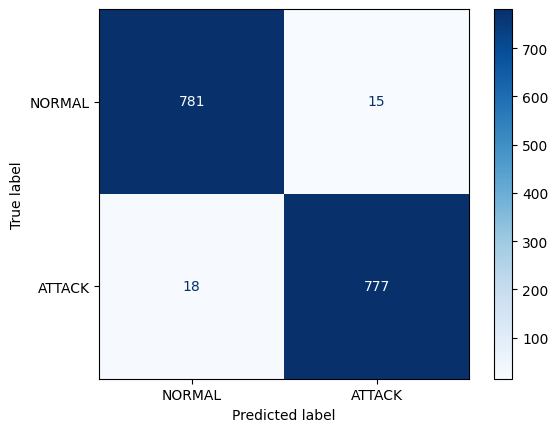

In [10]:
cm = confusion_matrix(
    y_val,
    y_val_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["NORMAL","ATTACK"]

)

disp.plot(cmap="Blues")

plt.show()

In [11]:
y_train_pred = rf.predict(X_train)

print("Train Accuracy :",
      accuracy_score(y_train,y_train_pred))

print("Validation Accuracy :",
      accuracy_score(y_val,y_val_pred))

Train Accuracy : 1.0
Validation Accuracy : 0.9792583280955374


In [12]:
print("="*60)

print("BASELINE RANDOM FOREST")

print("="*60)

print()

print("Train Accuracy      :",accuracy_score(y_train,y_train_pred))

print("Validation Accuracy :",accuracy_score(y_val,y_val_pred))

print("Validation Precision:",precision_score(y_val,y_val_pred))

print("Validation Recall   :",recall_score(y_val,y_val_pred))

print("Validation F1 Score :",f1_score(y_val,y_val_pred))

print("Validation ROC AUC  :",roc_auc_score(y_val,y_val_prob))

BASELINE RANDOM FOREST

Train Accuracy      : 1.0
Validation Accuracy : 0.9792583280955374
Validation Precision: 0.9810606060606061
Validation Recall   : 0.9773584905660377
Validation F1 Score : 0.9792060491493385
Validation ROC AUC  : 0.9956780759141619


RF TUNING

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
param_grid = {

    "n_estimators":[
        10,
        20,
        30,
        40,
        50,
        75,
        100,
        125,
        150
    ],

    "max_depth":[
        5,
        8,
        10,
        12,
        15,
        20,
        None
    ],

    "min_samples_split":[
        2,
        5,
        10,
        15
    ],

    "min_samples_leaf":[
        1,
        2,
        4,
        8
    ],

    "max_features":[
        "sqrt",
        "log2",
        None
    ],

    "bootstrap":[
        True,
        False
    ]
}

In [15]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [16]:
grid = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    verbose=2,

    n_jobs=-1

)

In [17]:
grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 6048 candidates, totalling 30240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [5, 8, 10, 12, 15, 20, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 15],
                         'n_estimators': [10, 20, 30, 40, 50, 75, 100, 125,
                                          150]},
             scoring='f1', verbose=2)

In [18]:
print(grid.best_params_)

{'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}


In [22]:
best_rf = grid.best_estimator_

print(best_rf)

RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=50, n_jobs=-1,
                       random_state=42)


In [23]:
y_val_pred = best_rf.predict(X_val)

y_val_prob = best_rf.predict_proba(X_val)[:,1]

In [24]:
print(classification_report(
    y_val,
    y_val_pred,
    target_names=[
        "NORMAL",
        "ATTACK"
    ]
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       796
      ATTACK       0.98      0.98      0.98       795

    accuracy                           0.98      1591
   macro avg       0.98      0.98      0.98      1591
weighted avg       0.98      0.98      0.98      1591



In [21]:
print("Accuracy :",accuracy_score(y_val,y_val_pred))

print("Precision :",precision_score(y_val,y_val_pred))

print("Recall :",recall_score(y_val,y_val_pred))

print("F1 :",f1_score(y_val,y_val_pred))

print("ROC AUC :",roc_auc_score(y_val,y_val_prob))

Accuracy : 0.9792583280955374
Precision : 0.9810606060606061
Recall : 0.9773584905660377
F1 : 0.9792060491493385
ROC AUC : 0.9956780759141619
